<a href="https://colab.research.google.com/github/mmubashirdev/AI/blob/main/ats.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [108]:
%matplotlib inline
from glob import glob
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import json

def calculate_ats_score(text, keywords):
    text = text.lower()
    score = 0
    for word in keywords:
        if word.lower() in text:
            score += 1
    return (score / len(keywords)) * 100

# Basic job keywords for scoring
job_keywords = ['Python', 'SQL', 'Machine Learning', 'Data Analysis', 'Management']

,content,annotation,extras,Skills,College Name,Graduation Year,Designation,Companies worked at,Email Address,Location,Name,Degree,Years of Experience,UNKNOWN,length
13,Ayushi Srivastava\nSenior Analyst - Cisco\n\nN...,"[{'label': ['Email Address'], 'points': [{'sta...",None,"[{'start': 1219, 'end': 1347, 'text': 'CSS (Le...","[{'start': 1176, 'end': 1203, 'text': 'Sumerma...","[{'start': 1170, 'end': 1173, 'text': '2012'},...","[{'start': 394, 'end': 408, 'text': 'Senior An...","[{'start': 410, 'end': 416, 'text': 'Cisco -'}]","[{'start': 1361, 'end': 1407, 'text': 'indeed....","[{'start': 42, 'end': 50, 'text': 'New Delhi'}]","[{'start': 0, 'end': 16, 'text': 'Ayushi Sriva...","[{'start': 1152, 'end': 1168, 'text': 'Senior ...",NaN,NaN,2110
181,Shreya Agnihotri\nSenior System Engineer at In...,"[{'label': ['Skills'], 'points': [{'start': 16...",None,"[{'start': 1632, 'end': 1835, 'text': 'Program...","[{'start': 1181, 'end': 1201, 'text': 'Galgoti...",NaN,"[{'start': 1080, 'end': 1120, 'text': 'Senior ...","[{'start': 1105, 'end': 1112, 'text': ' Infosy...","[{'start': 113, 'end': 160, 'text': 'indeed.co...","[{'start': 70, 'end': 78, 'text': 'Bengaluru'}]","[{'start': 0, 'end': 15, 'text': 'Shreya Agnih...","[{'start': 1166, 'end': 1178, 'text': 'B.Tech ...",NaN,NaN,1836
127,"Tanmoy Maity\nKolkata, West Bengal - Email me ...","[{'label': ['Skills'], 'points': [{'start': 31...",None,"[{'start': 319, 'end': 337, 'text': 'Hvac tech...","[{'start': 281, 'end': 286, 'text': 'Gtti -'}]",NaN,"[{'start': 185, 'end': 199, 'text': 'HVAC Tech...","[{'start': 202, 'end': 222, 'text': 'Infosys a...","[{'start': 55, 'end': 98, 'text': ' indeed.com...","[{'start': 289, 'end': 295, 'text': 'Kolkata'}...","[{'start': 0, 'end': 11, 'text': 'Tanmoy Maity'}]","[{'start': 264, 'end': 278, 'text': 'Diploma i...",NaN,NaN,488


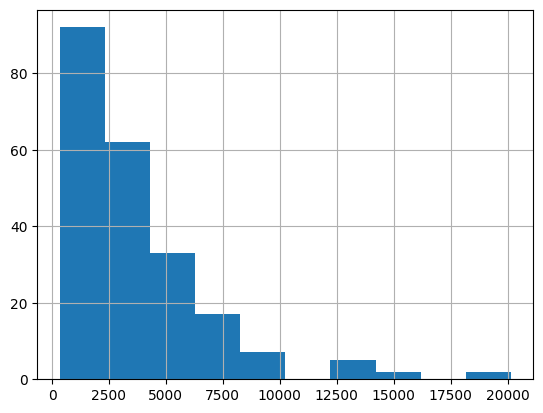

In [139]:
from collections import defaultdict
base_json = '/content/sample_data/dataset.json'
def pop_annot(raw_line):
    in_line = defaultdict(list, **raw_line)
    if 'annotation' in in_line:
        labels = in_line['annotation']
        for c_lab in labels:
            if len(c_lab['label'])>0:
                in_line[c_lab['label'][0]] += c_lab['points']
    return in_line
with open(base_json, 'r') as f:
    # data is jsonl and so we parse it line-by-line
    resume_data = [json.loads(f_line) for f_line in f.readlines()]
    resume_df = pd.DataFrame([pop_annot(line) for line in resume_data])
resume_df['length'] = resume_df['content'].map(len)
resume_df['length'].hist()
resume_df.sample(3)

# Just focus on any highlighted material
Try to find all the highlights

In [110]:
def extract_higlights(raw_line):
    in_line = defaultdict(list, **raw_line)
    if 'annotation' in in_line:
        labels = in_line['annotation']
        for c_lab in labels:
            if len(c_lab['label'])>0:
                in_line['highlight'] += [dict(category = c_lab['label'][0], **cpts) for cpts in c_lab['points']]
    return in_line
resume_hl_df = pd.DataFrame([extract_higlights(line) for line in resume_data])
resume_hl_df['length'] = resume_hl_df['content'].map(len)
resume_hl_df['length'].hist()
resume_hl_df.sample(3)

In [111]:
from string import ascii_lowercase, digits
valid_chars = ascii_lowercase+digits+'@., '
focus_col = 'highlight'
focus_df = resume_hl_df[['content', focus_col, 'length']].copy().dropna()
# clean up the text but maintain the length
focus_df['kosher_content'] = resume_df['content'].str.lower().map(lambda c_text: ''.join([c if c in valid_chars else ' ' for c in c_text]))
print(focus_col, 'with', focus_df.shape[0], 'complete results')
print('First result')
for _, c_row in focus_df.query('length<2000').sample(1, random_state = 20).iterrows():
    print(len(c_row['content']))
    for yoe in c_row[focus_col]:
        s,e = yoe['start'], yoe['end']
        print(yoe)
        print(c_row['content'][s:e+1])

### Simple Data Exploration

In [112]:
print("--- Dataset Info ---")
display(focus_df.info())
print("\n--- Missing Values ---")
display(focus_df.isnull().sum())
print("\n--- Statistics ---")
display(focus_df.describe())
print("\n--- First 5 Rows ---")
display(focus_df.head())

In [113]:
print("\n--- Last 5 Rows ---")
display(focus_df.tail())

### Additional Data Visualizations

In [114]:
import seaborn as sns
# Flatten the list of highlight categories for plotting
all_categories = []
for highlights_list in focus_df['highlight']:
    if isinstance(highlights_list, list):
        for item in highlights_list:
            if isinstance(item, dict) and 'category' in item:
                all_categories.append(item['category'])

if all_categories:
    plt.figure(figsize=(12, 6))
    # Fix for FutureWarning: Pass `palette` without assigning `hue` is deprecated.
    sns.countplot(y=all_categories, order=pd.Series(all_categories).value_counts().index, palette='viridis', hue=all_categories, legend=False)
    plt.title('Distribution of Highlight Categories')
    plt.xlabel('Count')
    plt.ylabel('Category')
    plt.show()
else:
    print("No highlight categories found to plot.")

### ATS Score Calculation

In [115]:
# Visualization of ATS scores distribution
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
sns.histplot(focus_df['ats_score'], kde=True, color='skyblue')
plt.title('Distribution of ATS Scores')
plt.xlabel('Score (%)')
plt.ylabel('Count')
plt.show()

In [116]:
# Relationship between Resume Length and ATS Score
plt.figure(figsize=(10, 6))
sns.scatterplot(x='length', y='ats_score', data=focus_df, alpha=0.6)
plt.title('Resume Length vs. ATS Score')
plt.xlabel('Resume Length (characters)')
plt.ylabel('ATS Score (%)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [117]:
# Distribution of Resume Length
plt.figure(figsize=(10, 6))
sns.histplot(focus_df['length'], bins=30, kde=True, color='purple')
plt.title('Distribution of Resume Lengths')
plt.xlabel('Length (characters)')
plt.ylabel('Count')
plt.show()

In [118]:
# Relationship between Resume Length and ATS Score
plt.figure(figsize=(10, 6))
sns.scatterplot(x='length', y='ats_score', data=focus_df, alpha=0.6)
plt.title('Resume Length vs. ATS Score')
plt.xlabel('Resume Length (characters)')
plt.ylabel('ATS Score (%)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [119]:
# Distribution of Resume Length
plt.figure(figsize=(10, 6))
sns.histplot(focus_df['length'], bins=30, kde=True, color='purple')
plt.title('Distribution of Resume Lengths')
plt.xlabel('Length (characters)')
plt.ylabel('Count')
plt.show()

### ATS Score Calculation

In [120]:
# Visualization of scores
import seaborn as sns
plt.figure(figsize=(10, 6))
sns.histplot(focus_df['ats_score'], kde=True, color='skyblue')
plt.title('Distribution of ATS Scores')
plt.xlabel('Score (%)')
plt.show()

In [121]:
def result_to_vec(in_row, focus_col):
    let_vec = in_row['kosher_content']
    attn_vec = np.zeros((len(let_vec)))
    for yoe in c_row[focus_col]:
        s,e = yoe['start'], yoe['end']
        attn_vec[s:e+1] = 1.0
    return let_vec, attn_vec

In [122]:
x_vec, y_vec = result_to_vec(c_row, focus_col)
loc_show = np.where(y_vec)[0][0]
fig, ax1 = plt.subplots(1, 1, figsize = (30, 2))
ax1.plot(y_vec[loc_show:(loc_show+200)])
ax1.set_xlabel('Letter')
ax1.set_ylabel('Attention')
ax1.set_xticks(range(200))
ax1.set_xticklabels(x_vec[loc_show:(loc_show+200)]);

In [123]:
from sklearn.model_selection import train_test_split
train_df, valid_df = train_test_split(focus_df, test_size = 0.2)
print(train_df.shape, valid_df.shape)

In [124]:
from sklearn.feature_extraction.text import CountVectorizer
feat_cv = CountVectorizer(analyzer='char')
from sklearn.preprocessing import LabelEncoder

In [125]:
let_enc = LabelEncoder()
let_enc.fit_transform(list(valid_chars))
print(let_enc.classes_.shape)

In [126]:
def result_to_fvec(in_row, focus_col):
    let_vec = in_row['kosher_content']
    attn_vec = np.zeros((len(let_vec)))
    flet_vec = let_enc.transform(list(let_vec))
    for yoe in c_row[focus_col]:
        s,e = yoe['start'], yoe['end']
        attn_vec[s:e+1] = 1.0
    return let_vec, flet_vec, attn_vec

In [127]:
x_vec, fx_vec, y_vec = result_to_fvec(c_row, focus_col)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (30, 6))
ax1.plot(y_vec[:200])
ax1.set_xlabel('Letter')
ax1.set_ylabel('Attention')
ax1.set_xticks(range(200))
ax1.set_xticklabels(x_vec[:200]);
for t_val in [0, 1]:
    ax2.plot((fx_vec*(y_vec==t_val))[:200], '-', label = 'Attention {}'.format(t_val))

In [128]:
from keras.preprocessing.sequence import pad_sequences
from scipy.ndimage import convolve1d
def package_df(in_df, minichunk_size = None, minichunk_upsampler = 10):
    train_x, train_y = [], []
    for _, c_row in in_df.iterrows():
        _, fx_vec, y_vec = result_to_fvec(c_row, focus_col)
        smooth_y_vec = convolve1d(y_vec.astype(np.float32), np.ones((10,))/5)
        if minichunk_size is not None:
            sample_count = fx_vec.shape[0]//minichunk_size*minichunk_upsampler//2
            # normal samples
            for s_idx in np.random.choice(range(fx_vec.shape[0]-minichunk_size), sample_count):
                train_x += [fx_vec[s_idx:(s_idx+minichunk_size)]]
                train_y += [np.expand_dims(smooth_y_vec[s_idx:(s_idx+minichunk_size)], -1)]
            # positive samples
            pos_sample_vec = convolve1d(y_vec.astype(np.float32), np.ones((32,))) # Use a longer window for positive samples
            pos_idx = np.where(pos_sample_vec>0)[0]
            if len(pos_idx)>0:
                for s_idx in np.random.choice(pos_idx, sample_count):
                    train_x += [fx_vec[s_idx:(s_idx+minichunk_size)]]
                    train_y += [np.expand_dims(smooth_y_vec[s_idx:(s_idx+minichunk_size)], -1)]
        else:
            train_x += [fx_vec]
            train_y += [np.expand_dims(y_vec, -1)]
    return pad_sequences(train_x), pad_sequences(train_y)
train_x, train_y = package_df(train_df.query('length>256'), minichunk_size = 256)
print(train_x.shape, train_y.shape)
valid_x, valid_y = package_df(valid_df, minichunk_size = 256) # Ensure consistent minichunk_size for validation data
print(valid_x.shape, valid_y.shape)

In [129]:
fig, ax1 = plt.subplots(1, 1, figsize = (8, 15))
ax1.matshow(train_y[:, :, 0])
ax1.set_aspect(.10)

# Try an LSTM

In [130]:
# # Replacing complex LSTM with a simpler evaluation of the Random Forest model
# # Fix: Use the correctly processed validation data (valid_x_fixed) with matching feature dimensions
# X_valid_flat = valid_x_fixed.reshape(valid_x_fixed.shape[0], -1)
# y_valid_flat = valid_y_fixed.reshape(valid_y_fixed.shape[0], -1).mean(axis=1) > 0.5

# y_pred = rf_model.predict(X_valid_flat)
# print(f'Model Accuracy: {accuracy_score(y_valid_flat, y_pred) * 100:.2f}%')
# print('\nClassification Report:\n', classification_report(y_valid_flat, y_pred))

### Machine Learning Models

In [131]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Using the pre-processed features from previously defined package_df logic
# We will flatten the 3D data into 2D for simple scikit-learn models
X_train_flat = train_x.reshape(train_x.shape[0], -1)
y_train_flat = train_y.reshape(train_y.shape[0], -1).mean(axis=1) > 0.5

# Train a simple Random Forest
rf_model = RandomForestClassifier(n_estimators=50, max_depth=10)
rf_model.fit(X_train_flat[:5000], y_train_flat[:5000]) # Sampled for speed

print("Random Forest Training Complete.")

### Model Accuracy and Evaluation

In [132]:
# Fix: Process validation data using the same chunk size as training data
valid_x_fixed, valid_y_fixed = package_df(valid_df, minichunk_size=256)
X_valid_flat = valid_x_fixed.reshape(valid_x_fixed.shape[0], -1)
y_valid_flat = valid_y_fixed.reshape(y_valid_fixed.shape[0], -1).mean(axis=1) > 0.5

# Run prediction
y_pred = rf_model.predict(X_valid_flat)
print(f"Model Accuracy: {accuracy_score(y_valid_flat, y_pred) * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_valid_flat, y_pred))

### Upload Resume and Get ATS Score
Run the cell below to upload a PDF resume. It will calculate a score based on how many job keywords are found.

In [133]:
from google.colab import files
import io
# Note: you might need to install pdfminer.six via !pip install pdfminer.six
try:
    from pdfminer.high_level import extract_text
except ImportError:
    !pip install pdfminer.six
    from pdfminer.high_level import extract_text

uploaded = files.upload()

for filename in uploaded.keys():
    resume_text = extract_text(io.BytesIO(uploaded[filename]))
    score = calculate_ats_score(resume_text, job_keywords)
    print(f"\n--- Results for {filename} ---")
    print(f"Simple ATS Score: {score:.2f}%")
    if score > 70:
        print("Status: Strong Match")
    else:
        print("Status: Needs Improvement")

In [134]:
from google.colab import drive
drive.mount('/content/drive')

In [135]:
train_x, train_y = package_df(train_df.query('length>1024'), minichunk_size = 1024)
print(train_x.shape, train_y.shape)
callbacks = [
    EarlyStopping(patience=5, verbose=1),
    ReduceLROnPlateau(patience=3, verbose=1),
    ModelCheckpoint('resume_attention.h5', verbose=1, save_best_only=True, save_weights_only=True)
]
results = simple_model.fit(
    train_x, train_y,
    epochs = 10,
    batch_size = 64,
    validation_data = (valid_x, valid_y),
    shuffle = True,
    callbacks=callbacks)

In [136]:
# # simple_model.load_weights('resume_attention.h5')

In [137]:
# # for _, c_row in focus_df.query('length<2000').sample(1, random_state = 20).iterrows():
# #     x_vec, fx_vec, y_vec = result_to_fvec(c_row, focus_col)

# # loc_show = np.where(y_vec)[0][0]
# # fig, (ax1) = plt.subplots(1, 1, figsize = (30, 3))
# # p_vec = simple_model.predict(np.expand_dims(fx_vec, 0))[0]
# # ax1.plot(y_vec[loc_show:(loc_show+200)], label = 'Ground Truth')
# # ax1.plot(p_vec[loc_show:(loc_show+200)], label = 'Prediction')
# # ax1.set_xlabel('Letter')
# # ax1.set_ylabel('Attention')
# # ax1.set_xticks(range(200))
# # ax1.set_xticklabels(x_vec[loc_show:(loc_show+200)]);

In [138]:
# # fig, (ax1, ax2) = plt.subplots(1, 2)
# # ax1.plot(p_vec)
# # ax2.hist(p_vec)

In [107]:
from google.colab import files
import io

# Install helper for PDF text extraction
!pip install pdfminer.six --quiet
from pdfminer.high_level import extract_text

print('Please upload a resume PDF file:')
uploaded = files.upload()

for filename in uploaded.keys():
    resume_text = extract_text(io.BytesIO(uploaded[filename]))
    user_score = calculate_ats_score(resume_text, job_keywords)
    print(f'\n--- Results for {filename} ---')
    print(f'ATS Compatibility Score: {user_score:.2f}%')
    if user_score > 70:
        print('Recommendation: Strong candidate for this role.')
    else:
        print('Recommendation: Consider adding more relevant keywords.')

Please upload a resume PDF file:


Saving Mubashir trainee MERN Software engineer resume.pdf to Mubashir trainee MERN Software engineer resume (2).pdf

--- Results for Mubashir trainee MERN Software engineer resume (2).pdf ---
ATS Compatibility Score: 40.00%
Recommendation: Consider adding more relevant keywords.
